In [2]:
#pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [4]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 59s 0us/step


In [5]:
x_train, x_test = x_train / 255.0, x_test / 255.0

In [6]:
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [7]:
model = models.Sequential()

In [8]:
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2, 2)))

C:\Users\Priya\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [10]:
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [11]:
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [12]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [13]:
history = model.fit(x_train, y_train, epochs=10, 
                    validation_data=(x_test, y_test))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 24ms/step - accuracy: 0.3602 - loss: 1.7298 - val_accuracy: 0.5475 - val_loss: 1.2443
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5892 - loss: 1.1629 - val_accuracy: 0.6332 - val_loss: 1.0446
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.6584 - loss: 0.9810 - val_accuracy: 0.6530 - val_loss: 0.9820
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.6937 - loss: 0.8778 - val_accuracy: 0.6642 - val_loss: 0.9509
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7169 - loss: 0.8007 - val_accuracy: 0.6809 - val_loss: 0.9320
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7386 - loss: 0.7384 - val_accuracy: 0.6973 - val_loss: 0.8778
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.7576 - loss: 0.6879 - val_accuracy: 0.7044 - val_loss: 0.8696
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.7772 -

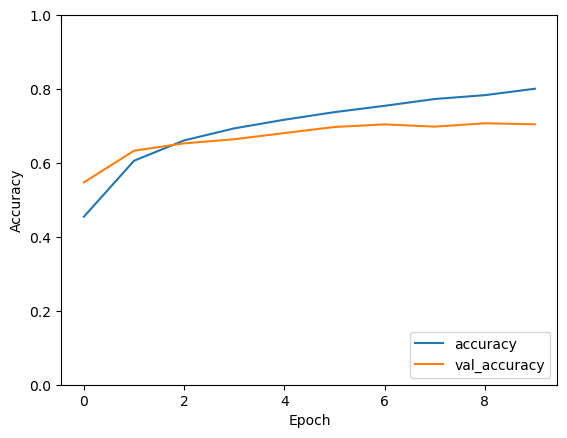

In [14]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [15]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test accuracy: {test_acc}")

313/313 - 2s - 7ms/step - accuracy: 0.7046 - loss: 0.8973
Test accuracy: 0.7045999765396118


In [16]:
from sklearn.metrics import classification_report
import numpy as np

In [17]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


In [18]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

In [19]:
print("Classification Report:\n")
print(classification_report(y_true_classes, y_pred_classes, target_names=[
    'Airplane', 'Automobile', 'Bird', 'Cat', 'Deer', 'Dog', 'Frog', 'Horse', 'Ship', 'Truck']))

Classification Report:

              precision    recall  f1-score   support

    Airplane       0.80      0.69      0.74      1000
  Automobile       0.87      0.81      0.83      1000
        Bird       0.57      0.64      0.60      1000
         Cat       0.50      0.51      0.51      1000
        Deer       0.72      0.60      0.65      1000
         Dog       0.60      0.59      0.60      1000
        Frog       0.81      0.76      0.79      1000
       Horse       0.78      0.74      0.76      1000
        Ship       0.69      0.88      0.77      1000
       Truck       0.75      0.84      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000

